In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

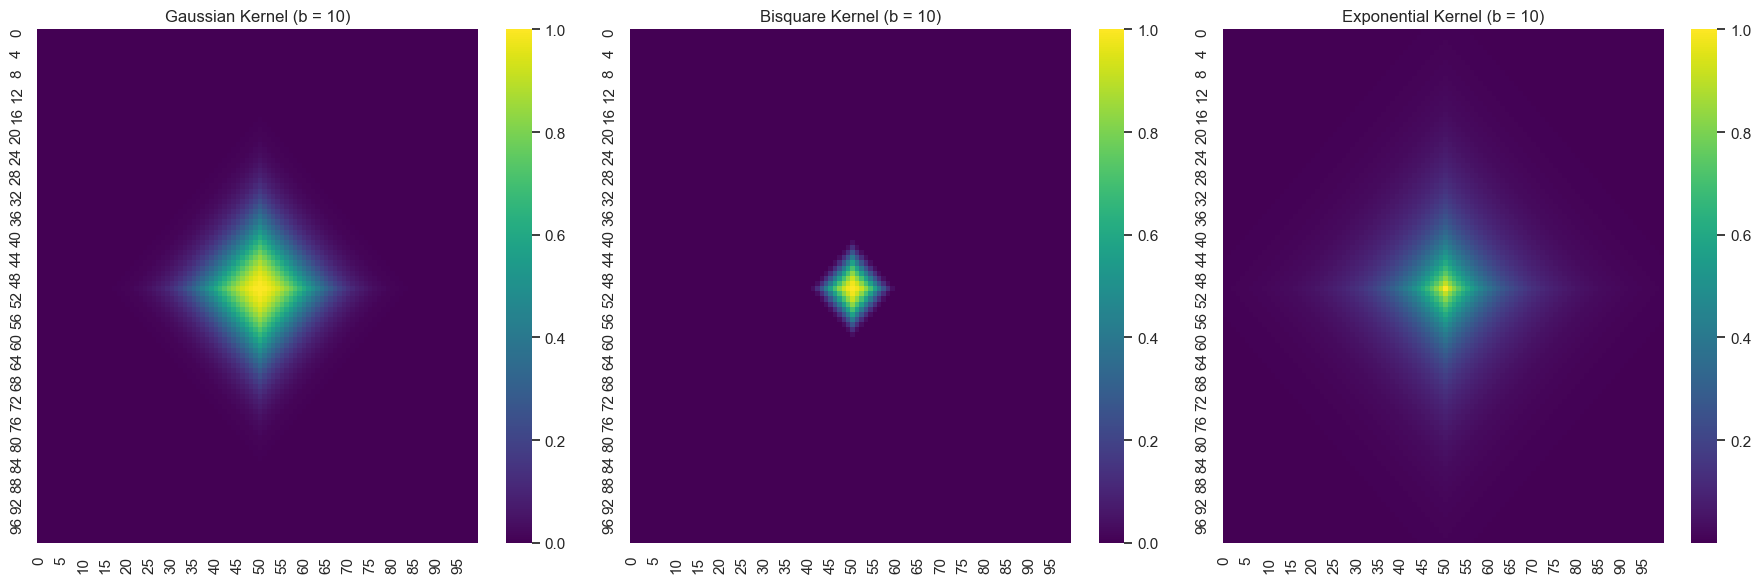

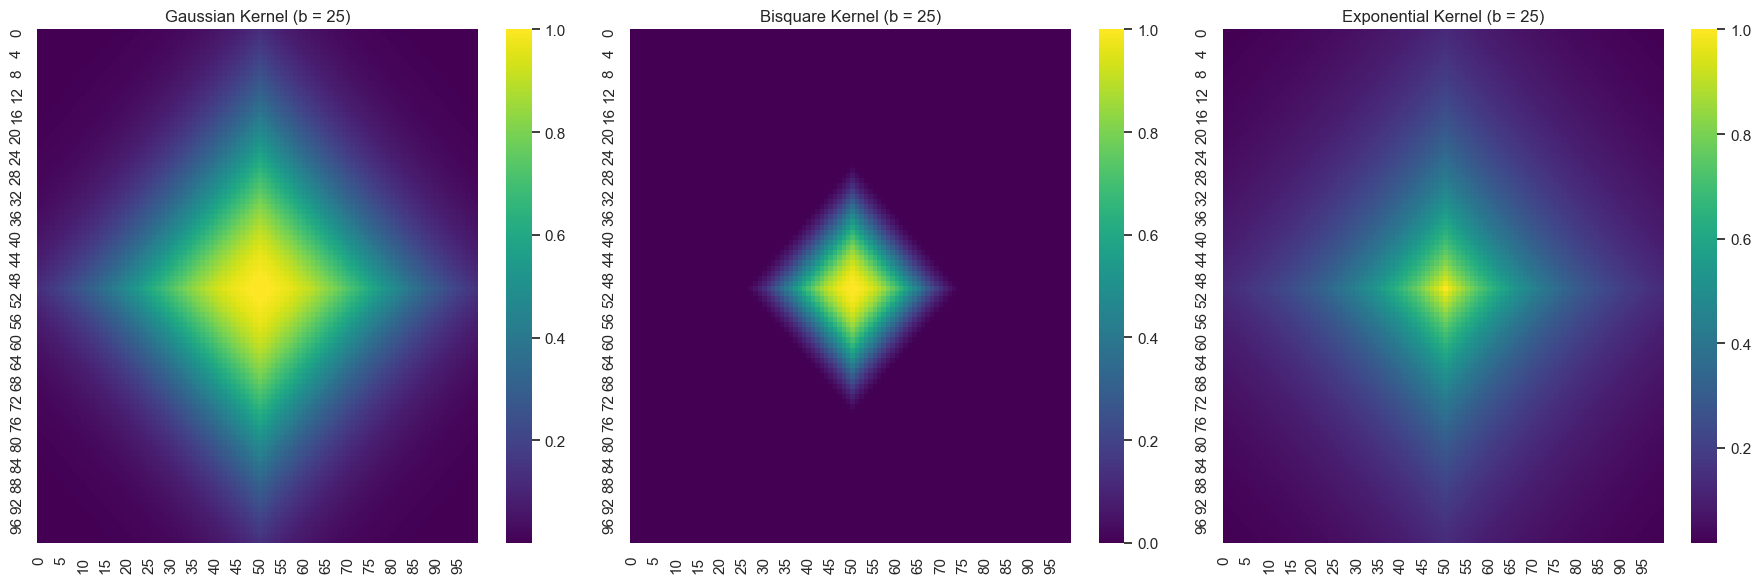

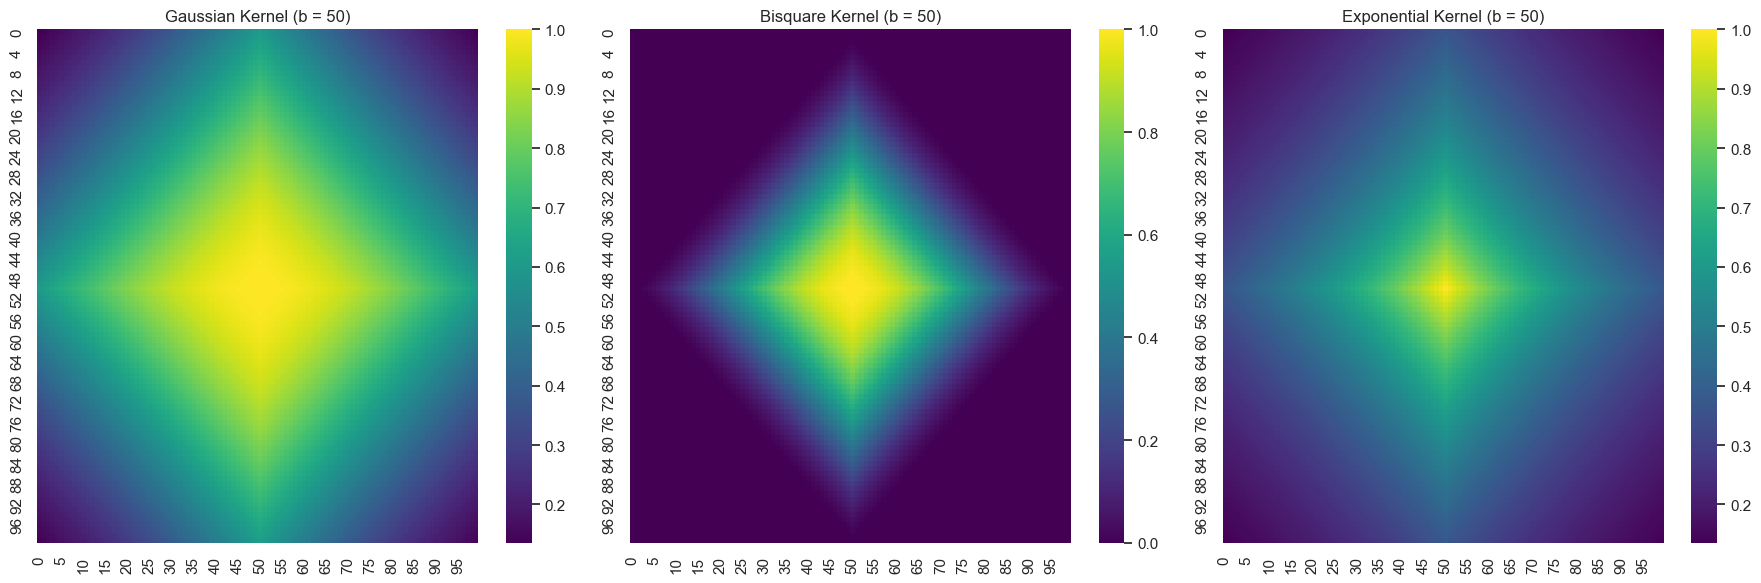

In [3]:

i_indices = np.arange(100)
j_indices = np.arange(100)
I, J = np.meshgrid(i_indices, j_indices, indexing='ij')

# Manhattan and Euclidean distances
manhattan_distance = np.abs(I - 50) + np.abs(J - 50)
euclidean_distance = np.sqrt((I - 50)**2 + (J - 50)**2)

# Kernel functions
def gaussian_kernel(D, b):
    return np.exp(- (D ** 2) / (2 * b ** 2))

def bisquare_kernel(D, b):
    return ((1 - (D / b) ** 2) ** 2) * (D < b) 

def exponential_kernel(D, b):
    return np.exp(- D / b)


def plot_kernels(D, bandwidth):
    
    W_gaussian = gaussian_kernel(D, bandwidth)
    W_bisquare = bisquare_kernel(D, bandwidth)
    W_exponential = exponential_kernel(D, bandwidth)

    
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Gaussian Kernel
    sns.heatmap(W_gaussian, cmap='viridis', ax=axs[0])
    axs[0].set_title(f'Gaussian Kernel (b = {bandwidth})')

    # Bisquare Kernel
    sns.heatmap(W_bisquare, cmap='viridis', ax=axs[1])
    axs[1].set_title(f'Bisquare Kernel (b = {bandwidth})')

    # Exponential Kernel
    sns.heatmap(W_exponential, cmap='viridis', ax=axs[2])
    axs[2].set_title(f'Exponential Kernel (b = {bandwidth})')

    plt.tight_layout()
    plt.show()



for b in [10, 25, 50]:
    plot_kernels(D = manhattan_distance, bandwidth=b)

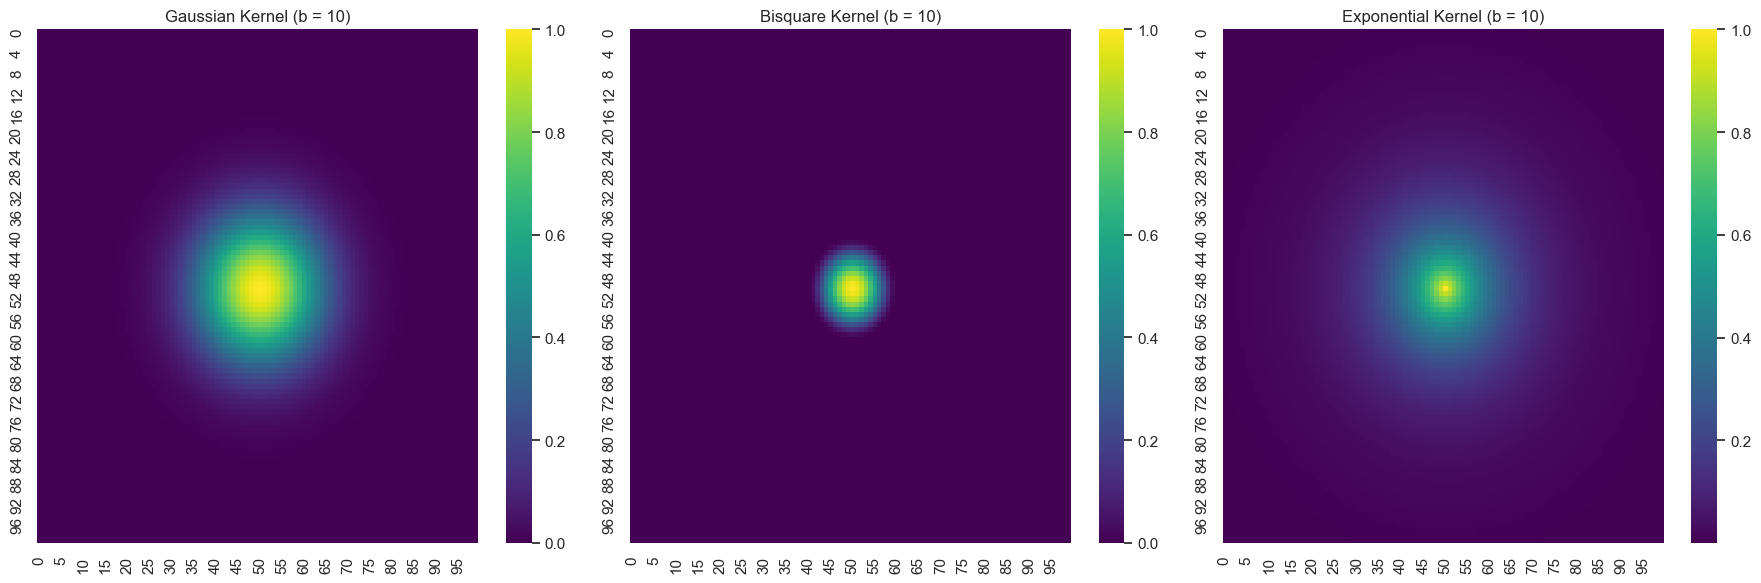

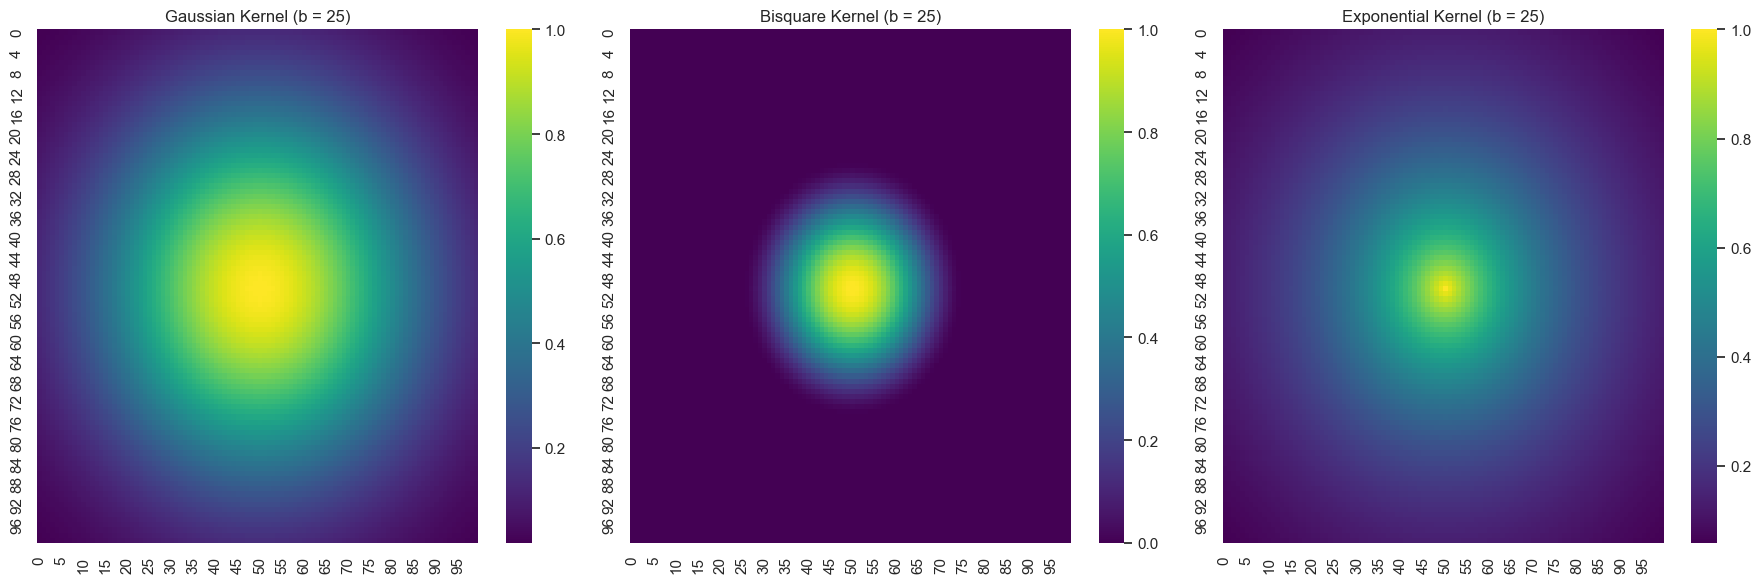

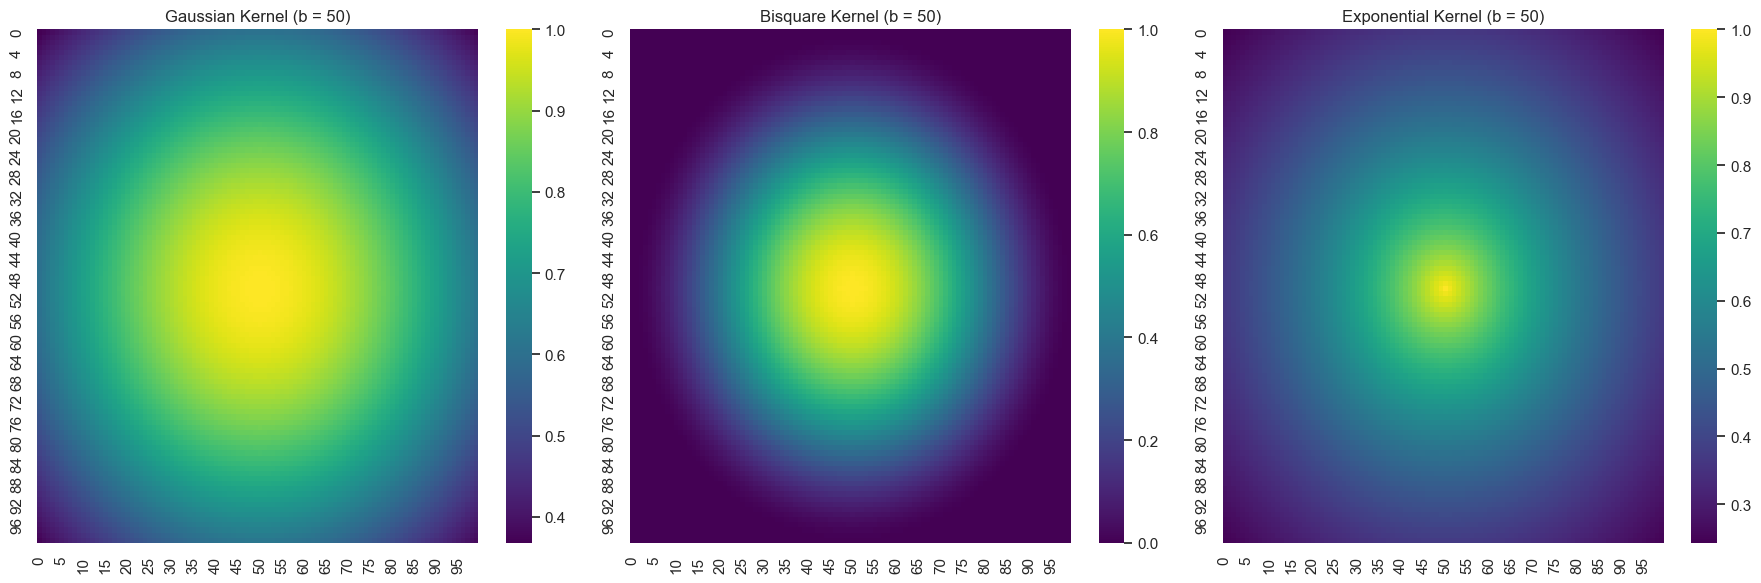

In [5]:

for b in [10, 25, 50]:
    plot_kernels(D = euclidean_distance, bandwidth=b)

In [9]:
pip install libpysal

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install mgwr

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import libpysal as ps
from libpysal.examples import available
from libpysal.examples import load_example
from libpysal.examples import get_path
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import compare_surfaces, truncate_colormap
import geopandas as gp
import folium

In [36]:

available()

,Name,Description,Installed
0,10740,"Albuquerque, New Mexico, Census 2000 Tract Dat...",True
1,AirBnB,"Airbnb rentals, socioeconomics, and crime in C...",False
2,Atlanta,"Atlanta, GA region homicide counts and rates",False
3,Baltimore,Baltimore house sales prices and hedonics,False
4,Bostonhsg,Boston housing and neighborhood data,False
...,...,...,...
94,taz,Traffic Analysis Zones in So. California,False
95,tokyo,Tokyo Mortality data,True
96,us_income,Per-capita income for the lower 48 US states 1...,True
97,virginia,Virginia counties shapefile,True


In [40]:

berlin = load_example('berlin')


berlin.installed

True

In [42]:

berlin.get_file_list()

['C:\\Users\\wilfo\\anaconda3\\Lib\\site-packages\\libpysal\\examples\\berlin\\prenzlauer.zip',
 'C:\\Users\\wilfo\\anaconda3\\Lib\\site-packages\\libpysal\\examples\\berlin\\prenz_bound.zip',
 'C:\\Users\\wilfo\\anaconda3\\Lib\\site-packages\\libpysal\\examples\\berlin\\README.md']

In [46]:

prenz = gp.read_file(berlin.get_path('prenzlauer.zip'))
prenz_bound = gp.read_file(berlin.get_path('prenz_bound.zip'))

In [26]:

type(prenz)

geopandas.geodataframe.GeoDataFrame

In [48]:

type(prenz)

geopandas.geodataframe.GeoDataFrame

In [50]:

len(prenz)

2203

In [32]:
prenz_bound.head()

,neighbourh,geometry
0,Helmholtzplatz,"POLYGON ((1496989.669 6899662.266, 1497008.148..."


In [52]:



map = folium.Map(location=[52.542986,13.427986], zoom_start=13.5, control_scale=True)


folium.GeoJson(prenz_bound).add_to(map)


folium.GeoJson(prenz,
               marker=folium.Circle(radius=10, fill_color="red", fill_opacity=0.4, color="red", weight=1)).add_to(map)

map

In [54]:
b_y = np.log(prenz['price'].values.reshape((-1, 1)))
b_X = prenz[['review_sco','accommodat','bathrooms']].values
u = prenz['X']
v = prenz['Y']
b_coords = list(zip(u, v))

In [56]:
selector = Sel_BW(b_coords, b_y, b_X)
bw = selector.search()
print(bw)

192.0


In [57]:
gwr_model = GWR(b_coords, b_y, b_X, bw)
gwr_results = gwr_model.fit()
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                2203
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            406.306
Log-likelihood:                                                   -1263.871
AIC:                                                               2535.742
AICc:                                                              2537.769
BIC:                                                             -16520.662
R2:                                                                   0.272
Adj. R2:                                                              0.271

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [60]:
gwr_results.params[0:5]

array([[ 3.30479996e+00,  1.61014298e-03,  2.06243405e-01,
        -2.67321919e-02],
       [ 3.43635569e+00, -4.51930353e-04,  1.95844944e-01,
         5.37474550e-02],
       [ 3.27912291e+00,  2.92768647e-03,  2.12363255e-01,
        -8.10919052e-02],
       [ 2.88779932e+00,  5.06056110e-03,  2.45744327e-01,
         4.65164479e-02],
       [ 2.89309002e+00,  3.06784769e-03,  1.67282256e-01,
         3.42487452e-01]])

In [62]:
gwr_results.localR2[0:10]

array([[0.39583113],
       [0.41660429],
       [0.35650484],
       [0.43641022],
       [0.44784271],
       [0.41771337],
       [0.42162229],
       [0.41387561],
       [0.36649332],
       [0.46269692]])

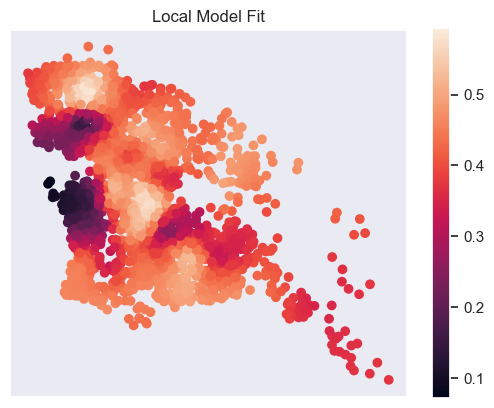

In [64]:
prenz['R2'] = gwr_results.localR2
prenz.plot('R2', legend = True)
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.title("Local Model Fit")
plt.show()

In [66]:
W_1 = gwr_results.W[0]
W_matrix = np.diag(W_1)

In [68]:
b_X_1 = np.hstack([np.ones((b_X.shape[0], 1)), b_X])

In [70]:
inverse_matrix = np.linalg.inv(b_X_1.T@W_matrix@b_X_1)

In [72]:
beta_1 = inverse_matrix@b_X_1.T@W_matrix@b_y
beta_1

array([[ 3.30479996e+00],
       [ 1.61014298e-03],
       [ 2.06243405e-01],
       [-2.67321919e-02]])

In [74]:
gwr_results.params[0]

array([ 3.30479996e+00,  1.61014298e-03,  2.06243405e-01, -2.67321919e-02])